# PromptIR – Blind Rain/Snow Removal
**Restormer-64 backbone · prompt_len=8 · Stage 1 (180 ep) + Stage 2 FT (40 ep)**

**Before running:**
1. Set Runtime → Change runtime type → **GPU** (T4 or better)
2. Place `hw4_realse_dataset.zip` on Google Drive **or** upload directly to `/content/`
3. Place `train.py` on Google Drive (same folder) **or** upload to `/content/`


In [1]:
# 0. Check GPU
!nvidia-smi

Sat May 30 21:04:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [4]:
# 2. Set paths and copy files into working directory
import os, shutil
from pathlib import Path

# ─── Edit these paths if your files are in a different Drive folder ───
DRIVE_ROOT  = Path('/content/drive/MyDrive/vis_hw4')   # adjust if needed
DRIVE_ZIP   = DRIVE_ROOT / 'hw4_realse_dataset.zip'
DRIVE_TRAIN = DRIVE_ROOT / 'train.py'

# Colab direct-upload fallbacks
COLAB_ZIP   = Path('/content/hw4_realse_dataset.zip')
COLAB_TRAIN = Path('/content/train.py')

WORK_DIR = Path('/content/vis_hw4')
WORK_DIR.mkdir(parents=True, exist_ok=True)

# Copy zip
zip_dest = WORK_DIR / 'hw4_realse_dataset.zip'
if not zip_dest.exists():
    if DRIVE_ZIP.exists():
        shutil.copy2(DRIVE_ZIP, zip_dest); print('Copied zip from Drive')
    elif COLAB_ZIP.exists():
        shutil.move(str(COLAB_ZIP), zip_dest); print('Moved zip from /content')
    else:
        print('WARNING: zip not found. Upload hw4_realse_dataset.zip to Drive or /content/')
else:
    print('zip already present')

# Copy train.py
train_dest = WORK_DIR / 'train.py'
shutil.copy2(DRIVE_TRAIN, train_dest); print('Copied train.py from Drive')
if not train_dest.exists():
    if DRIVE_TRAIN.exists():
        shutil.copy2(DRIVE_TRAIN, train_dest); print('Copied train.py from Drive')
    elif COLAB_TRAIN.exists():
        shutil.copy2(str(COLAB_TRAIN), train_dest); print('Copied train.py from /content')
    else:
        print('WARNING: train.py not found. Upload it to Drive or /content/')
else:
    print('train.py already present')

print('zip exists   :', zip_dest.exists())
print('train.py exists:', train_dest.exists())

Copied zip from Drive
Copied train.py from Drive
train.py already present
zip exists   : True
train.py exists: True


In [4]:
# 3. Install / verify dependencies (most are pre-installed on Colab)
!pip install -q torch torchvision matplotlib numpy Pillow

In [34]:
# 4. Quick sanity check – parse train.py
import ast
src = open('/content/vis_hw4/train.py').read()
ast.parse(src)
print('train.py syntax OK  |', f'{len(src):,} chars')

train.py syntax OK  | 32,241 chars


In [40]:
# 5. FULL TRAINING — Stage 1 (180 ep) + Stage 2 fine-tune (40 ep)
# Estimated time: ~6-8 h on T4, ~2-3 h on A100
# The script auto-resumes if the cell is interrupted and re-run.
!cd /content && python vis_hw4/train.py \
  --data_root vis_hw4 \
  --ckpt_dir vis_hw4/checkpoints \
  --pred_dir vis_hw4/predictions \
  --plot_dir vis_hw4/plots \
  --dim 64 \
  --prompt_len 8 \
  --crop 192 \
  --batch 8 \
  --workers 2 \
  --s1_epochs 180 \
  --s1_lr 2e-4 \
  --s1_warmup 15 \
  --s1_ema 0.999 \
  --s2_epochs 40 \
  --s2_lr 5e-5 \
  --s2_warmup 3 \
  --s2_ema 0.9995

Found 3200 train pairs  |  100 test images
Train: 3040  Val: 160
Model params: 48.6M

STAGE 1 — Base Training (180 epochs)
[stage1] Ep    1/180  loss=0.09690  PSNR rain=15.48 snow=17.75 tot=16.56  (192s)
  ✓ saved best (16.5574 dB) → vis_hw4/checkpoints/stage1_best.pth
[stage1] Ep    2/180  loss=0.07649  PSNR rain=16.58 snow=20.17 tot=18.29  (183s)
  ✓ saved best (18.2873 dB) → vis_hw4/checkpoints/stage1_best.pth
[stage1] Ep    3/180  loss=0.06558  PSNR rain=17.68 snow=21.96 tot=19.71  (183s)
  ✓ saved best (19.7092 dB) → vis_hw4/checkpoints/stage1_best.pth
[stage1] Ep    4/180  loss=0.06095  PSNR rain=18.78 snow=23.37 tot=20.96  (183s)
  ✓ saved best (20.9597 dB) → vis_hw4/checkpoints/stage1_best.pth
[stage1] Ep    5/180  loss=0.05703  PSNR rain=19.92 snow=24.37 tot=22.03  (183s)
  ✓ saved best (22.0323 dB) → vis_hw4/checkpoints/stage1_best.pth
[stage1] Ep    6/180  loss=0.05449  PSNR rain=21.06 snow=24.91 tot=22.89  (183s)
  ✓ saved best (22.8896 dB) → vis_hw4/checkpoints/stage1_best

In [ ]:
# 5b. STAGE 1 ONLY (if you want to run stages separately)
# !cd /content && python vis_hw4/train.py \\
# --data_root vis_hw4 --ckpt_dir vis_hw4/checkpoints \\
# --pred_dir vis_hw4/predictions --plot_dir vis_hw4/plots \\
# --dim 64 --prompt_len 8 --crop 192 --batch 2 --workers 2 \\
# --s1_epochs 180 --s1_lr 2e-4 --s1_warmup 15 --s1_ema 0.999 \\
# --s2_epochs 0

In [ ]:
# 6. Inference only (training already done — load best checkpoint)
# !cd /content && python vis_hw4/train.py \\
# --data_root vis_hw4 --ckpt_dir vis_hw4/checkpoints \\
# --pred_dir vis_hw4/predictions --plot_dir vis_hw4/plots \\
# --dim 64 --prompt_len 8 --infer_only

── Stage 1 — PSNR (Rain / Snow / Total) ──


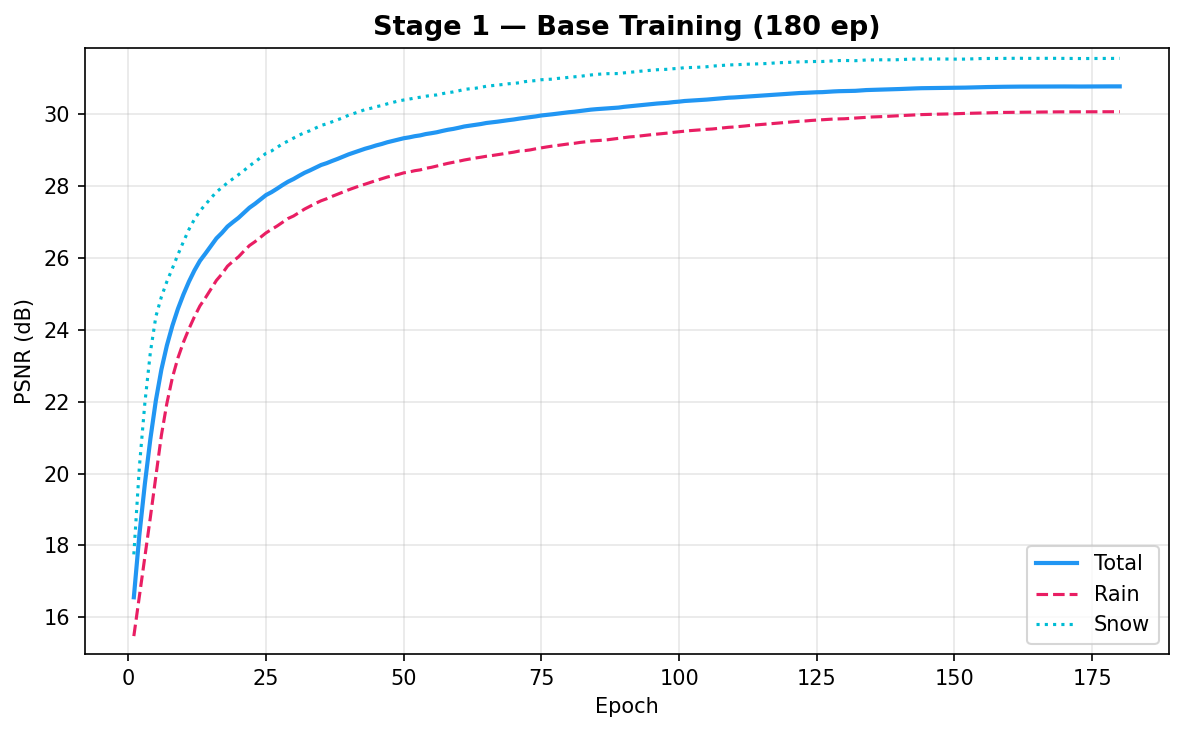

── Stage 1 — Charbonnier Loss ──


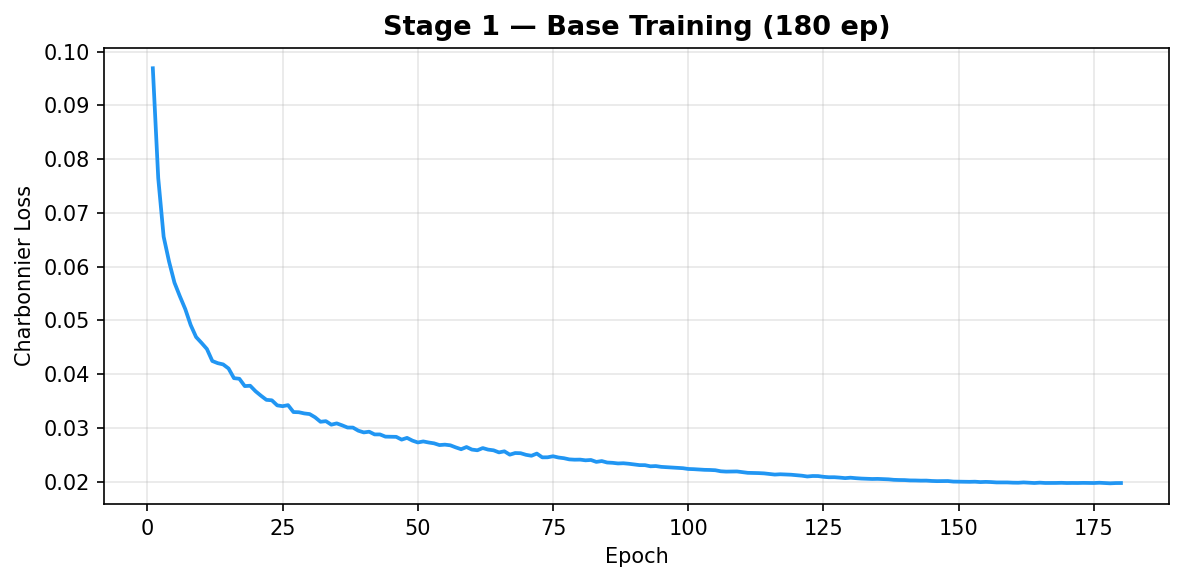

── Stage 2 — PSNR (Rain / Snow / Total) ──


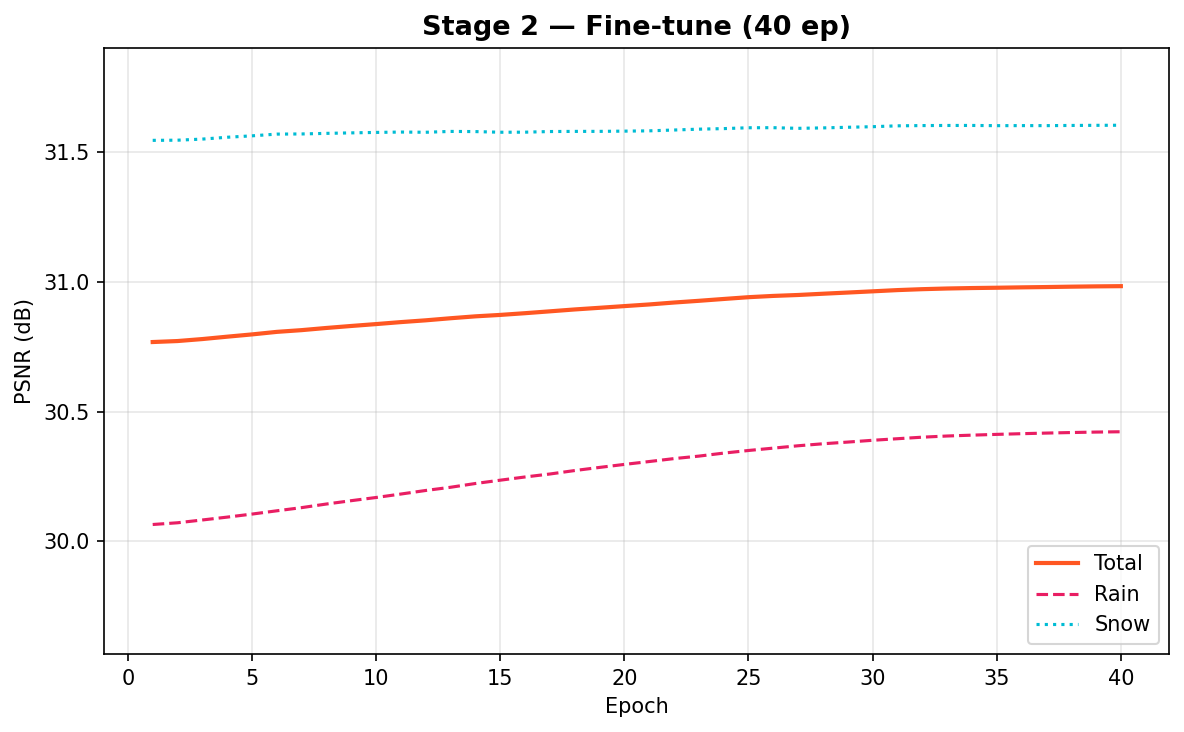

── Stage 2 — Charbonnier Loss ──


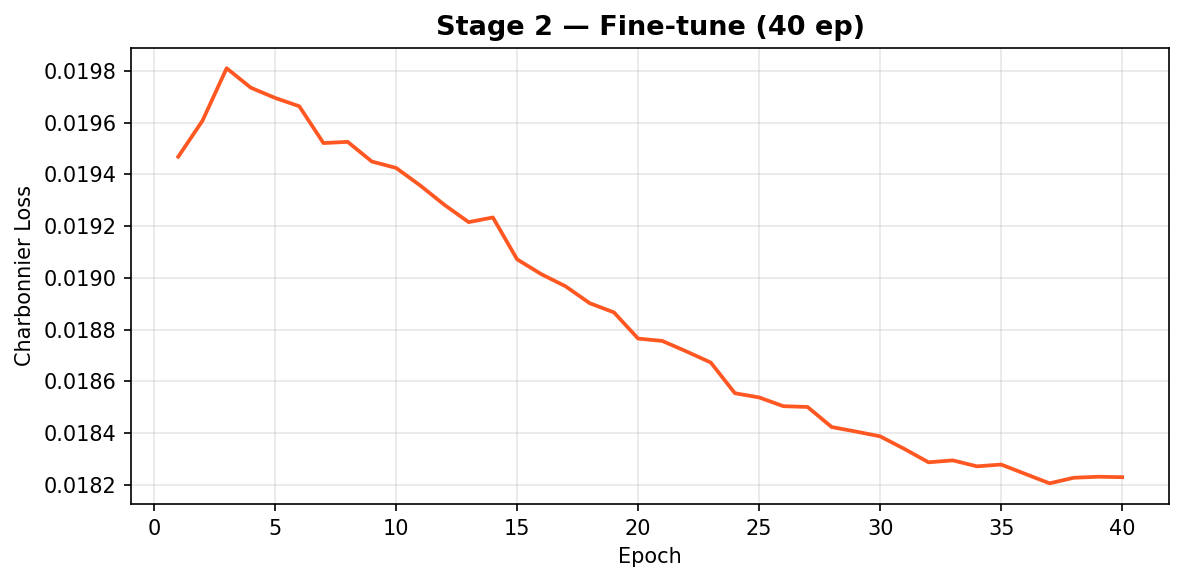

── Final — PSNR across all stages ──


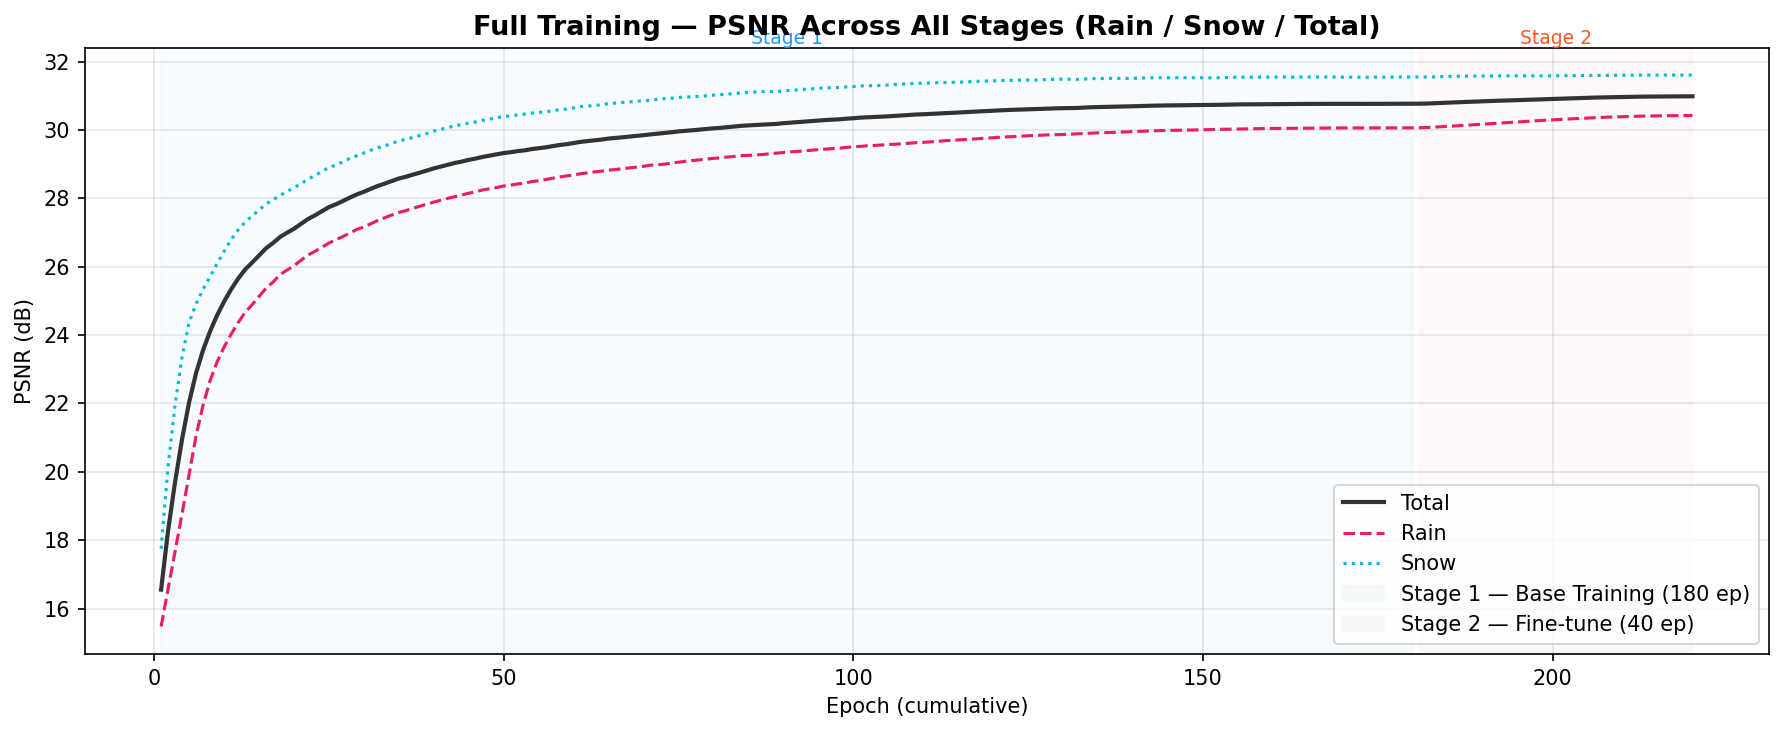

── Final — Loss across all stages ──


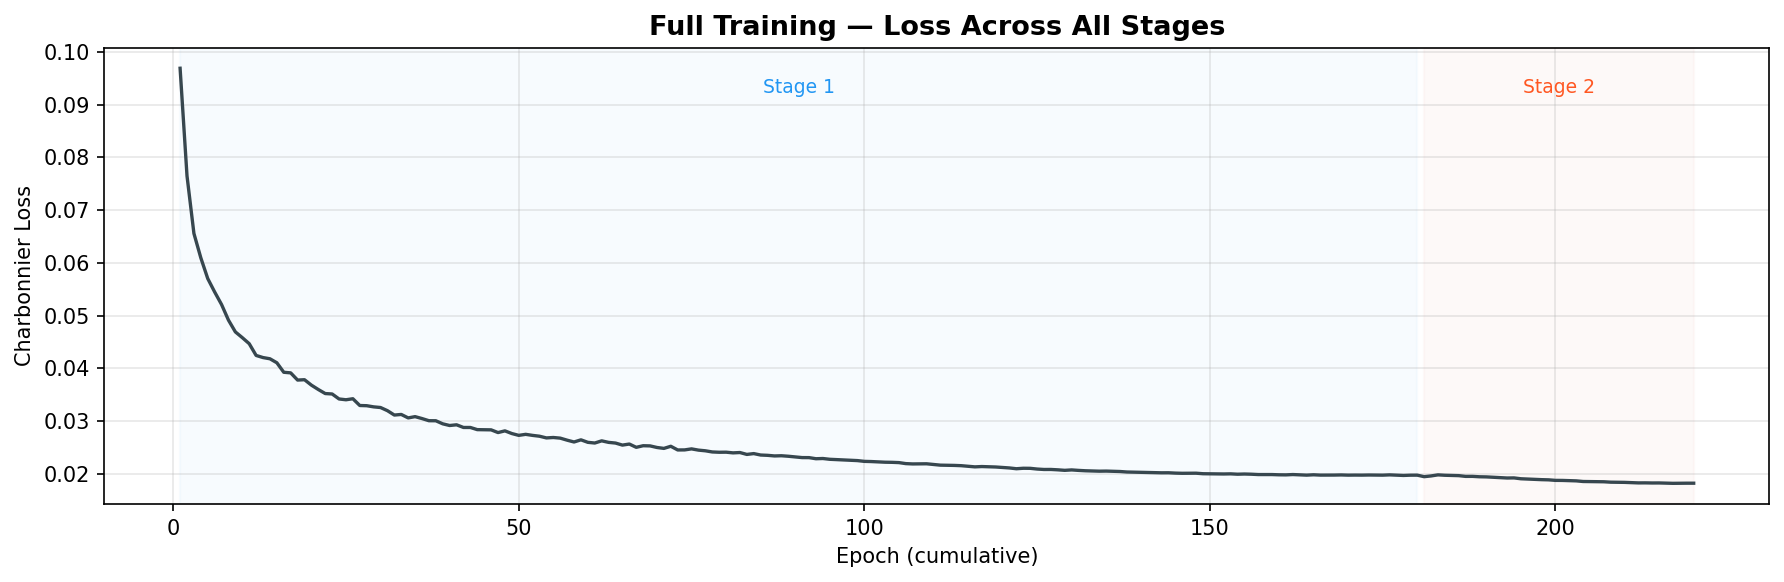

In [41]:
# 7. Display training curves (6 separate figures)
from IPython.display import Image, display
from pathlib import Path

plot_dir = Path("/content/vis_hw4/plots")

plots = [
    ("psnr_stage1.png",        "Stage 1 — PSNR (Rain / Snow / Total)"),
    ("loss_stage1.png",        "Stage 1 — Charbonnier Loss"),
    ("psnr_stage2.png",        "Stage 2 — PSNR (Rain / Snow / Total)"),
    ("loss_stage2.png",        "Stage 2 — Charbonnier Loss"),
    ("psnr_final_combined.png","Final — PSNR across all stages"),
    ("loss_final_combined.png","Final — Loss across all stages"),
]

for fname, title in plots:
    p = plot_dir / fname
    if p.exists():
        print(f"── {title} ──")
        display(Image(filename=str(p)))
    else:
        print(f"{fname} not found yet — run training first.")


In [ ]:
# 8. Re-generate plots from saved history.json (without re-training)
!cd /content && python vis_hw4/train.py \
    --ckpt_dir  vis_hw4/checkpoints \
    --plot_dir  vis_hw4/plots \
--plots_only

In [42]:
# 9. Save checkpoints to Drive (strongly recommended for long runs)
import shutil
from pathlib import Path
dst = Path('/content/drive/MyDrive/vis_hw4_checkpoints')
dst.mkdir(parents=True, exist_ok=True)
shutil.copytree('/content/vis_hw4/checkpoints', str(dst), dirs_exist_ok=True)
print(f'Checkpoints saved to {dst}')

Checkpoints saved to /content/drive/MyDrive/vis_hw4_checkpoints


In [43]:
# 9b. Download pred.npz directly
from google.colab import files
from pathlib import Path

npz_path = Path('/content/vis_hw4/predictions/pred.npz')
if npz_path.exists():
    files.download(str(npz_path))
else:
    print('pred.npz not found — run inference first (cell 5 or 6).')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [44]:
# 10. Download all outputs (checkpoints + plots + pred.npz)
import shutil
from google.colab import files
shutil.make_archive('/content/vis_hw4_outputs', 'zip', '/content/vis_hw4')
files.download('/content/vis_hw4_outputs.zip')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **INFERENCE**

In [3]:
from pathlib import Path
import shutil

DRIVE_ROOT   = Path('/content/drive/MyDrive/vis_hw4_checkpoints')  # where weights were saved
DRIVE_OUT    = Path('/content/drive/MyDrive/vis_hw4_outputs')       # where results will be saved
WORK_DIR     = Path('/content/vis_hw4')

for d in [WORK_DIR/'checkpoints', WORK_DIR/'plots', WORK_DIR/'predictions',
          WORK_DIR/'dataset', DRIVE_OUT/'plots', DRIVE_OUT/'predictions']:
    d.mkdir(parents=True, exist_ok=True)

# Copy checkpoints + history from Drive into working directory
for fname in ['stage1_best.pth', 'stage2_best.pth', 'history.json']:
    src = DRIVE_ROOT / fname
    dst = WORK_DIR / 'checkpoints' / fname
    if src.exists():
        shutil.copy2(src, dst)
        print(f'Copied {fname}')
    else:
        print(f'WARNING: {fname} not found at {src}')

# Also copy train.py from Drive
for src_path in [DRIVE_ROOT / 'train.py',
                 Path('/content/drive/MyDrive/train.py')]:
    if src_path.exists():
        shutil.copy2(src_path, WORK_DIR / 'train.py')
        print(f'Copied train.py from {src_path}')
        break
else:
    print('WARNING: train.py not found on Drive — upload it manually')

Copied stage1_best.pth
Copied stage2_best.pth
Copied history.json


In [5]:
from pathlib import Path
import shutil

zip_dest = Path('/content/vis_hw4/hw4_realse_dataset.zip')
ext_dir  = Path('/content/vis_hw4/dataset')

# Look for zip on Drive
for candidate in [
    Path('/content/drive/MyDrive/vis_hw4/hw4_realse_dataset.zip'),
    Path('/content/drive/MyDrive/vis_hw4_checkpoints/hw4_realse_dataset.zip'),
    Path('/content/hw4_realse_dataset.zip'),
]:
    if candidate.exists():
        shutil.copy2(candidate, zip_dest)
        print(f'Copied zip from {candidate}')
        break
else:
    print('WARNING: zip not found — upload hw4_realse_dataset.zip to /content/ or Drive')

# Extract if not already done
if zip_dest.exists() and not any(ext_dir.rglob('*.png')):
    import zipfile
    print('Extracting...')
    with zipfile.ZipFile(zip_dest) as zf:
        zf.extractall(ext_dir)
    print('Extracted.')
elif any(ext_dir.rglob('*.png')):
    print('Dataset already extracted.')

Extracting...
Extracted.


In [6]:
# 4. Verify history.json content
import json
from pathlib import Path

hist = json.load(open('/content/vis_hw4/checkpoints/history.json'))
for stage, data in hist.items():
    n = len(data['total'])
    best = max(data['total'])
    best_r = max(data['rain'])
    best_s = max(data['snow'])
    print(f'{stage}: {n} epochs  |  best total={best:.4f}  rain={best_r:.4f}  snow={best_s:.4f}')


stage1: 180 epochs  |  best total=30.7662  rain=30.0616  snow=31.5477
stage2: 40 epochs  |  best total=30.9837  rain=30.4219  snow=31.6046


In [7]:
# 5. Regenerate all 6 plots → saved to Drive immediately
!pip install -q matplotlib

import json, math
from pathlib import Path
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import shutil

hist      = json.load(open('/content/vis_hw4/checkpoints/history.json'))
plot_dir  = Path('/content/vis_hw4/plots')
DRIVE_OUT = Path('/content/drive/MyDrive/vis_hw4_outputs')
(DRIVE_OUT / 'plots').mkdir(parents=True, exist_ok=True)

COLOURS = {'stage1': '#2196F3', 'stage2': '#FF5722'}
LABELS  = {'stage1': 'Stage 1 — Base Training (180 ep)',
            'stage2': 'Stage 2 — Fine-tune (40 ep)'}

def save(fig, name):
    local = plot_dir / name
    drive = DRIVE_OUT / 'plots' / name
    fig.savefig(local, dpi=150, bbox_inches='tight')
    shutil.copy2(local, drive)
    plt.close(fig)
    print(f'Saved {name} → Drive')

# ── Per-stage PSNR & Loss ────────────────────────────────────────────────
for sname, data in hist.items():
    eps = range(1, len(data['total']) + 1)
    col = COLOURS.get(sname, '#333')
    lbl = LABELS.get(sname, sname)

    # PSNR
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(eps, data['total'], color=col,       label='Total',  linewidth=2)
    ax.plot(eps, data['rain'],  color='#E91E63',  label='Rain',   linewidth=1.5, linestyle='--')
    ax.plot(eps, data['snow'],  color='#00BCD4',  label='Snow',   linewidth=1.5, linestyle=':')
    ax.set_title(lbl, fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('PSNR (dB)')
    lo = max(0, min(min(data['rain']), min(data['snow']), min(data['total'])) - 0.5)
    hi = max(max(data['rain']), max(data['snow']), max(data['total'])) + 0.3
    ax.set_ylim(lo, hi); ax.legend(loc='lower right'); ax.grid(alpha=0.3)
    plt.tight_layout()
    save(fig, f'psnr_{sname}.png')

    # Loss
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(eps, data['loss'], color=col, linewidth=1.8)
    ax.set_title(lbl, fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Charbonnier Loss'); ax.grid(alpha=0.3)
    plt.tight_layout()
    save(fig, f'loss_{sname}.png')

# ── Combined PSNR ────────────────────────────────────────────────────────
all_rain, all_snow, all_tot, all_loss = [], [], [], []
boundaries = [0]
stage_names = list(hist.keys())
for sname in stage_names:
    d = hist[sname]
    all_rain.extend(d['rain']); all_snow.extend(d['snow'])
    all_tot.extend(d['total']); all_loss.extend(d['loss'])
    boundaries.append(len(all_tot))

bg_colours = {'stage1': '#E3F2FD', 'stage2': '#FBE9E7'}

fig, ax = plt.subplots(figsize=(12, 5))
x = range(1, len(all_tot) + 1)
ax.plot(x, all_tot,  color='#333333', label='Total', linewidth=2)
ax.plot(x, all_rain, color='#E91E63', label='Rain',  linewidth=1.5, linestyle='--')
ax.plot(x, all_snow, color='#00BCD4', label='Snow',  linewidth=1.5, linestyle=':')
for i, sname in enumerate(stage_names):
    x0, x1 = boundaries[i] + 1, boundaries[i + 1]
    ax.axvspan(x0, x1, alpha=0.25, color=bg_colours.get(sname, '#F5F5F5'))
    ax.text((x0 + x1) / 2, max(all_tot) + 0.05,
            LABELS.get(sname, sname).split('—')[0].strip(),
            ha='center', va='bottom', fontsize=9, color=COLOURS.get(sname, '#555'))
ax.set_xlabel('Epoch (cumulative)'); ax.set_ylabel('PSNR (dB)')
ax.set_title('Full Training — PSNR Across All Stages', fontsize=13, fontweight='bold')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout()
save(fig, 'psnr_final_combined.png')

# ── Combined Loss ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(range(1, len(all_loss) + 1), all_loss, color='#37474F', linewidth=1.6)
for i, sname in enumerate(stage_names):
    x0, x1 = boundaries[i] + 1, boundaries[i + 1]
    ax.axvspan(x0, x1, alpha=0.25, color=bg_colours.get(sname, '#F5F5F5'))
    ax.text((x0 + x1) / 2, max(all_loss) * 0.98,
            LABELS.get(sname, sname).split('—')[0].strip(),
            ha='center', va='top', fontsize=9, color=COLOURS.get(sname, '#555'))
ax.set_xlabel('Epoch (cumulative)'); ax.set_ylabel('Charbonnier Loss')
ax.set_title('Full Training — Loss Across All Stages', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
save(fig, 'loss_final_combined.png')

print('\nAll plots saved to Drive ✓')


Saved psnr_stage1.png → Drive
Saved loss_stage1.png → Drive
Saved psnr_stage2.png → Drive
Saved loss_stage2.png → Drive
Saved psnr_final_combined.png → Drive
Saved loss_final_combined.png → Drive

All plots saved to Drive ✓



── Stage 1 — PSNR (Rain / Snow / Total) ──


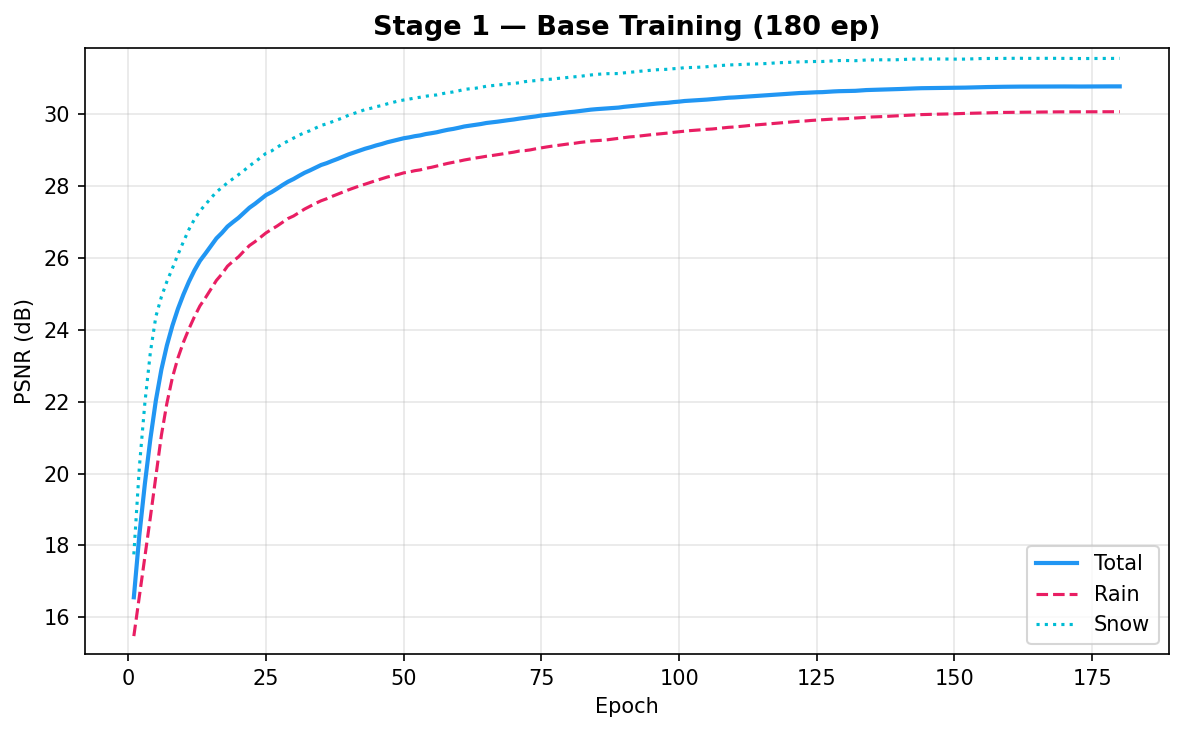


── Stage 1 — Charbonnier Loss ──


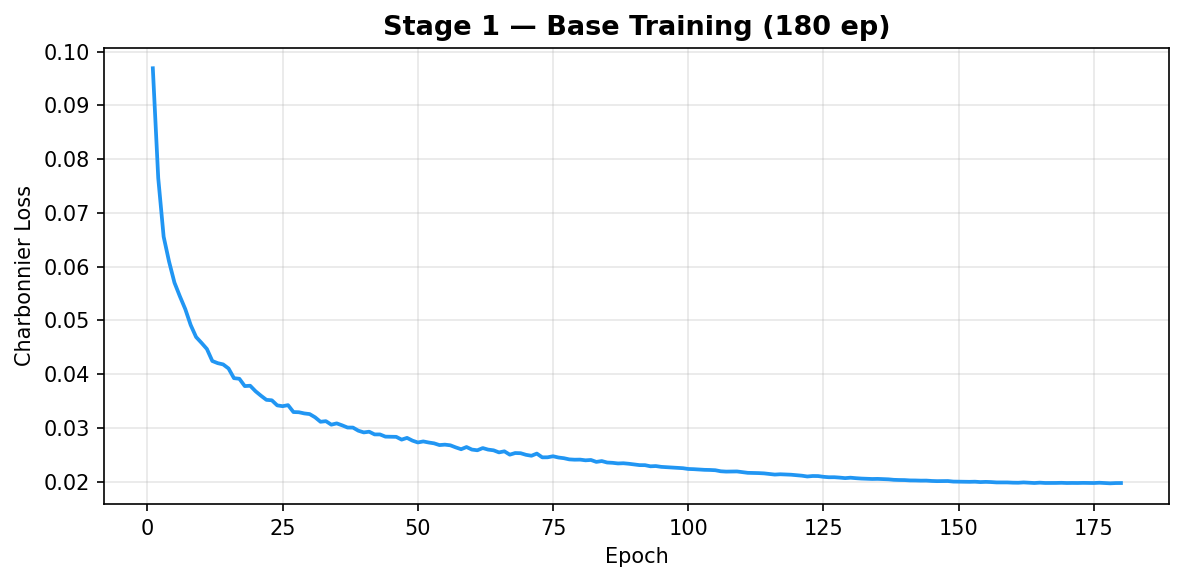


── Stage 2 — PSNR (Rain / Snow / Total) ──


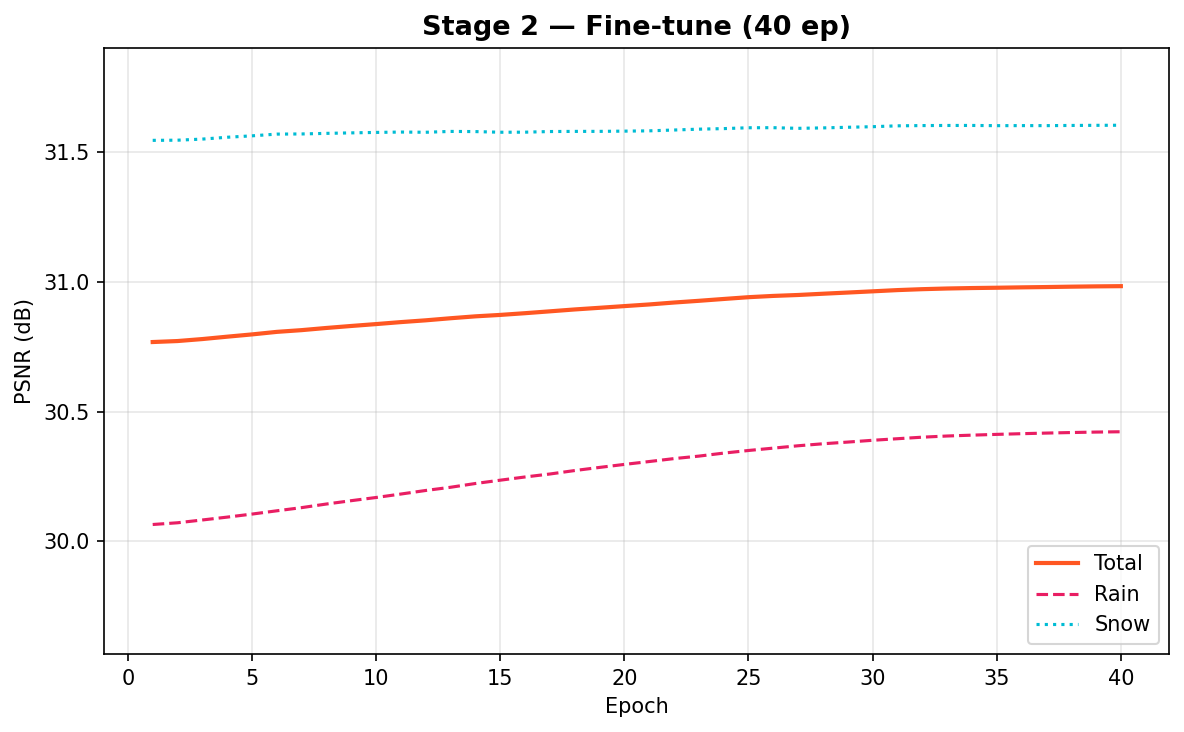


── Stage 2 — Charbonnier Loss ──


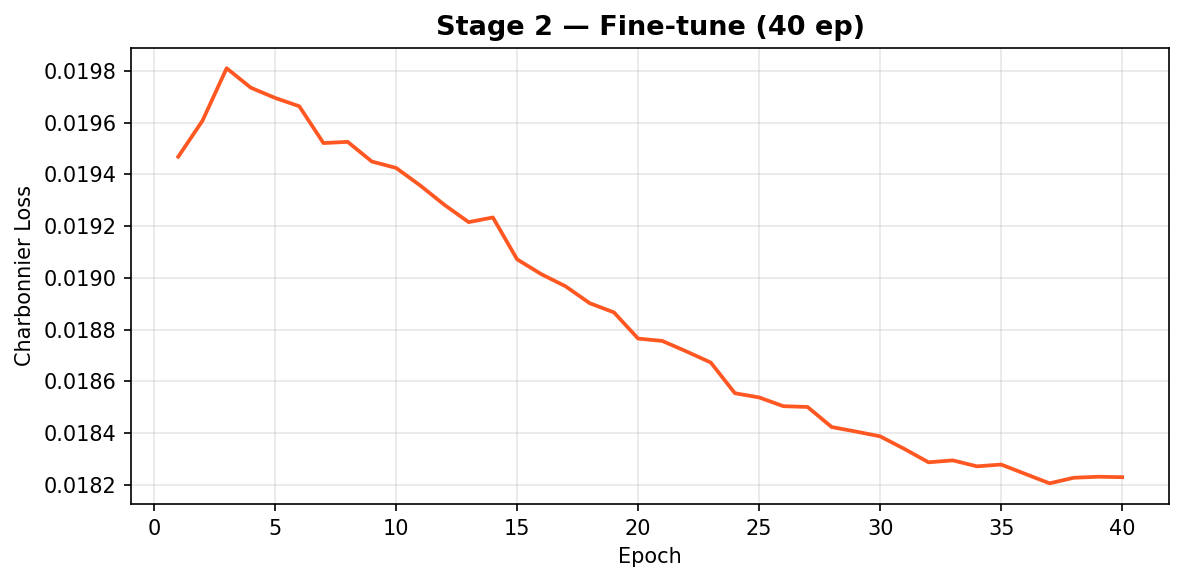


── Final — PSNR across all stages ──


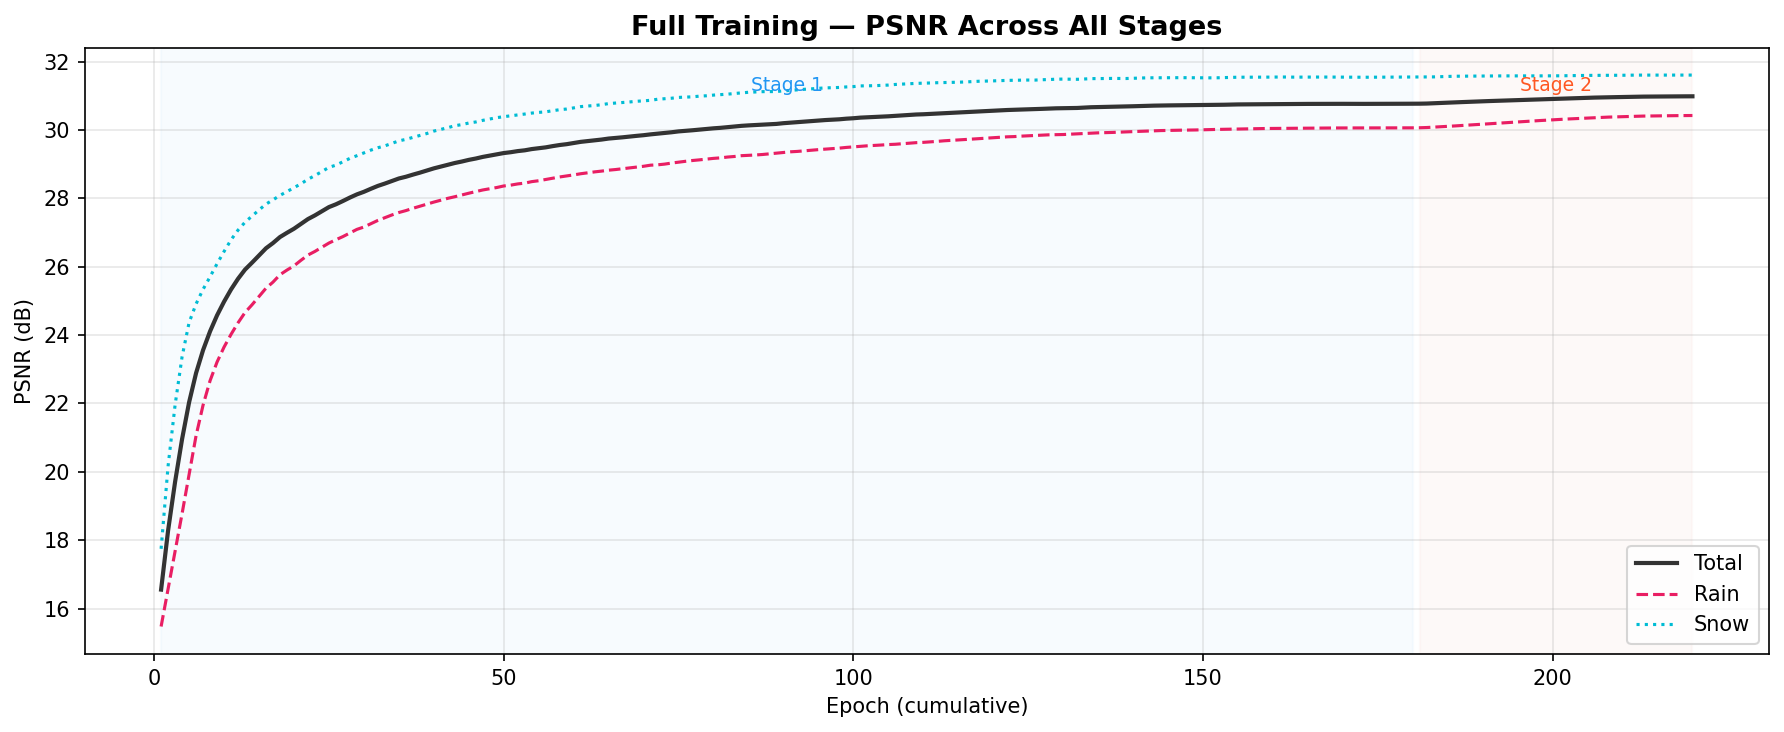


── Final — Loss across all stages ──


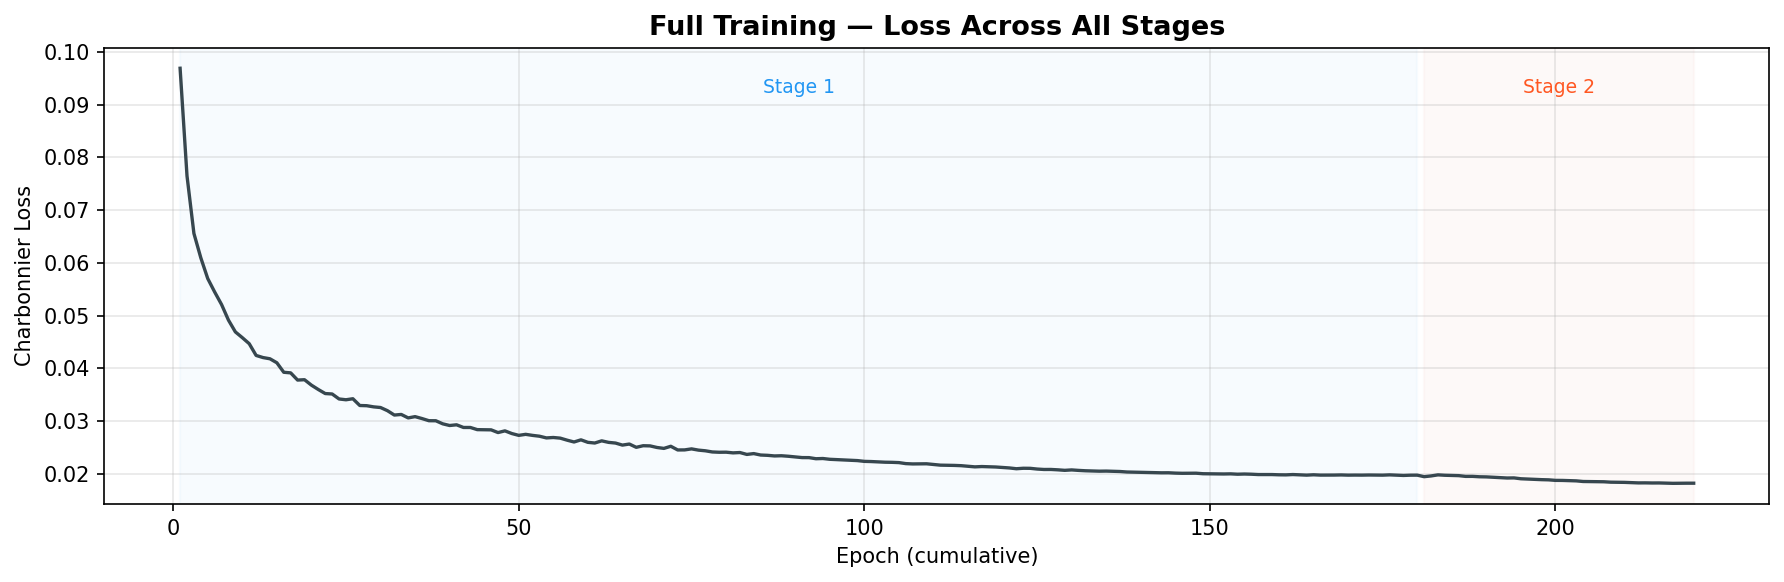

In [8]:
# 6. Display plots inline to verify
from IPython.display import Image, display
from pathlib import Path

plot_dir = Path('/content/vis_hw4/plots')
plots = [
    ('psnr_stage1.png',         'Stage 1 — PSNR (Rain / Snow / Total)'),
    ('loss_stage1.png',         'Stage 1 — Charbonnier Loss'),
    ('psnr_stage2.png',         'Stage 2 — PSNR (Rain / Snow / Total)'),
    ('loss_stage2.png',         'Stage 2 — Charbonnier Loss'),
    ('psnr_final_combined.png', 'Final — PSNR across all stages'),
    ('loss_final_combined.png', 'Final — Loss across all stages'),
]
for fname, title in plots:
    p = plot_dir / fname
    if p.exists():
        print(f'\n── {title} ──')
        display(Image(filename=str(p)))
    else:
        print(f'MISSING: {fname}')


In [9]:
# 7. Run inference → pred.npz saved to Drive immediately
# Loads stage2_best.pth (falls back to stage1_best.pth if not present)
import torch, numpy as np
from pathlib import Path
from PIL import Image as PILImage
import torchvision.transforms.functional as TF
import shutil, sys

sys.path.insert(0, '/content/vis_hw4')
from train import PromptIR, find_pairs, list_images, basename_map

DRIVE_OUT  = Path('/content/drive/MyDrive/vis_hw4_outputs')
CKPT_DIR   = Path('/content/vis_hw4/checkpoints')
PRED_DIR   = Path('/content/vis_hw4/predictions')
EXT_DIR    = Path('/content/vis_hw4/dataset')
(DRIVE_OUT / 'predictions').mkdir(parents=True, exist_ok=True)
PRED_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

# Load model
model = PromptIR(dim=64, prompt_len=8).to(device)
ckpt_path = CKPT_DIR / 'stage2_best.pth'
if not ckpt_path.exists():
    ckpt_path = CKPT_DIR / 'stage1_best.pth'
print(f'Loading {ckpt_path}')
ckpt = torch.load(ckpt_path, map_location=device)
model.load_state_dict(ckpt['ema'])
model.eval()
print('Model loaded.')

# Find test images
_, test_paths = find_pairs(EXT_DIR)
print(f'Found {len(test_paths)} test images')

@torch.no_grad()
def tta_predict(model, x):
    preds = []
    for hf in [False, True]:
        for vf in [False, True]:
            xi = x
            if hf: xi = xi.flip(-1)
            if vf: xi = xi.flip(-2)
            p = model(xi)
            if vf: p = p.flip(-2)
            if hf: p = p.flip(-1)
            preds.append(p)
    return torch.stack(preds).mean(0)

# Run inference
images_dict = {}
for i, p in enumerate(test_paths):
    img = TF.to_tensor(PILImage.open(p).convert('RGB')).unsqueeze(0).to(device)
    pred = tta_predict(model, img).squeeze(0).clamp(0, 1)
    arr = (pred.cpu().numpy() * 255).round().astype(np.uint8)  # (3, H, W)
    images_dict[p.name] = arr
    if (i + 1) % 10 == 0:
        print(f'  {i+1}/{len(test_paths)}')

# Save pred.npz locally then copy to Drive immediately
npz_local = PRED_DIR / 'pred.npz'
np.savez(npz_local, **images_dict)
npz_drive = DRIVE_OUT / 'predictions' / 'pred.npz'
shutil.copy2(npz_local, npz_drive)
print(f'\npred.npz ({len(images_dict)} images) saved to Drive ✓')
print(f'  → {npz_drive}')


Device: cuda
Loading /content/vis_hw4/checkpoints/stage2_best.pth
Model loaded.
Found 100 test images
  10/100
  20/100
  30/100
  40/100
  50/100
  60/100
  70/100
  80/100
  90/100
  100/100

pred.npz (100 images) saved to Drive ✓
  → /content/drive/MyDrive/vis_hw4_outputs/predictions/pred.npz


In [10]:
# 8. Verify pred.npz
import numpy as np
from pathlib import Path

data = np.load('/content/vis_hw4/predictions/pred.npz')
keys = sorted(data.files, key=lambda k: int(Path(k).stem))
print(f'Total images: {len(keys)}')
print(f'Keys (first 5): {keys[:5]}')
k = keys[0]
print(f'Shape of {k}: {data[k].shape}  dtype: {data[k].dtype}')
print('All shapes uniform:', len(set(str(data[k].shape) for k in keys)) == 1)


Total images: 100
Keys (first 5): ['0.png', '1.png', '2.png', '3.png', '4.png']
Shape of 0.png: (3, 256, 256)  dtype: uint8
All shapes uniform: True


In [11]:
# 9. Save everything to Drive as a zip (final backup)
import shutil
from pathlib import Path

DRIVE_OUT = Path('/content/drive/MyDrive/vis_hw4_outputs')
zip_path  = Path('/content/drive/MyDrive/vis_hw4_full_backup')
shutil.make_archive(str(zip_path), 'zip', '/content/vis_hw4')
print(f'Full backup saved to {zip_path}.zip ✓')


Full backup saved to /content/drive/MyDrive/vis_hw4_full_backup.zip ✓


In [12]:
from google.colab import runtime
runtime.unassign()

## Directory layout after running
```
vis_hw4/
├── hw4_realse_dataset.zip
├── dataset/                  ← auto-extracted
├── checkpoints/
│   ├── stage1_best.pth
│   ├── stage2_best.pth
│   └── history.json
├── predictions/              ← test-set outputs (TTA)
├── plots/
│   ├── psnr_curves.png       ← per-stage PSNR (rain/snow/total)
│   ├── loss_curves.png       ← per-stage Charbonnier loss
│   └── psnr_combined.png     ← full training PSNR across stages
└── train.py
```

## Key hyperparameters
| Param | Stage 1 | Stage 2 |
|---|---|---|
| Epochs | 180 | 40 |
| LR | 2e-4 | 5e-5 |
| Warmup | 15 ep | 3 ep |
| EMA decay | 0.999 | 0.9995 |
| Augmentation | hflip+vflip+rot90 | hflip only |
| dim / prompt_len | 64 / 8 | 64 / 8 |
| Train/Val split | 95% / 5% | — |

## Resuming after disconnect
Re-run cell 5. The script detects existing checkpoints and resumes from the last saved epoch automatically.
